# Análisis Anual: PM2.5 y Crecimiento Vehicular
## Guatemala 2022-2024

**Objetivo:** Visualizar tendencias año a año de:
- Concentración promedio de PM2.5
- Crecimiento del parque vehicular
- Comparación interanual

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualizaciones
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11
%matplotlib inline

print("✓ Librerías cargadas")

✓ Librerías cargadas


---
## 1. Carga de Datos

In [2]:
# Cargar datos procesados (si ya existen del análisis anterior)
# O cargar datos originales

try:
    # Opción 1: Datos ya procesados
    df = pd.read_csv('datos_procesados_pm25_vehiculos.csv')
    df['fecha_pm25'] = pd.to_datetime(df['fecha_pm25'])
    print("✓ Datos procesados cargados desde CSV")
    
except FileNotFoundError:
    # Opción 2: Cargar datos originales
    print("Cargando datos originales...")
    
    # Cargar PM2.5
    df_pm25 = pd.read_csv('Partículas PM2.5-data-2022-2024.csv')
    df_pm25['valor_pm25'] = df_pm25['Particulas_PM25'].str.extract(r'(\d+\.?\d*)').astype(float)
    df_pm25['timestamp'] = pd.to_datetime(df_pm25['Time'], errors='coerce')
    df_pm25 = df_pm25.dropna(subset=['timestamp'])
    
    # Agregar a nivel mensual
    df_pm25_mensual = df_pm25.set_index('timestamp')['valor_pm25'].resample('ME').agg(
        pm25_promedio='mean',
        pm25_std='std',
        pm25_min='min',
        pm25_max='max',
        n_mediciones='count'
    ).reset_index()
    df_pm25_mensual.rename(columns={'timestamp': 'fecha'}, inplace=True)
    df_pm25_mensual['anio_mes'] = df_pm25_mensual['fecha'].dt.to_period('M')
    
    # Cargar vehículos
    df_vehiculos = pd.read_csv('INE_PARQUE_VEHICULAR_2022_2024.csv')
    df_vehiculos['fecha'] = pd.to_datetime(df_vehiculos['FECHA_ALZA'], format='%Y/%m', errors='coerce')
    df_vehiculos['anio_mes'] = df_vehiculos['fecha'].dt.to_period('M')
    df_vehiculos = df_vehiculos.dropna(subset=['fecha'])
    
    # Agregar vehículos por mes
    df_vehiculos_mensual = df_vehiculos.groupby('anio_mes').agg({
        'CANTIDAD': 'sum',
        'fecha': 'first'
    }).reset_index()
    df_vehiculos_mensual.rename(columns={'CANTIDAD': 'total_vehiculos'}, inplace=True)
    
    # Merge
    df = pd.merge(
        df_pm25_mensual,
        df_vehiculos_mensual,
        on='anio_mes',
        how='inner',
        suffixes=('_pm25', '_vehiculos')
    )
    
    print("✓ Datos originales procesados")

# Verificar estructura
print(f"\nDimensiones: {df.shape}")
print(f"Periodo: {df['fecha_pm25'].min()} → {df['fecha_pm25'].max()}")
display(df.head())

✓ Datos procesados cargados desde CSV

Dimensiones: (34, 32)
Periodo: 2022-03-31 00:00:00 → 2024-12-31 00:00:00


,fecha_pm25,pm25_promedio,pm25_std,pm25_min,pm25_max,n_mediciones,anio_mes,total_vehiculos,fecha_vehiculos,AMBULANCIA,...,MICROBUS,MOTO,PANEL,PICK UP,TRIMOTO,VEHICULO RUSTICO,anio,mes,trimestre,epoca_seca
0,2022-03-31,34.741995,48.576288,0.0,418.0,3779,2022-03,9309,2022-03-01,4.0,...,73.0,6169.0,52.0,399.0,71.0,11.0,2022,3,1,True
1,2022-04-30,33.175436,31.176778,1.0,206.0,5797,2022-04,9167,2022-04-01,46.0,...,112.0,6365.0,49.0,377.0,56.0,11.0,2022,4,2,True
2,2022-05-31,35.115454,22.736478,2.0,219.0,7163,2022-05,9714,2022-05-01,2.0,...,61.0,6532.0,78.0,437.0,184.0,7.0,2022,5,2,True
3,2022-06-30,16.860261,22.070367,1.0,1364.0,7743,2022-06,11045,2022-06-01,3.0,...,86.0,7658.0,106.0,550.0,147.0,5.0,2022,6,2,False
4,2022-07-31,10.955846,10.738618,1.0,450.0,8561,2022-07,8932,2022-07-01,5.0,...,60.0,5693.0,70.0,547.0,195.0,9.0,2022,7,3,False


---
## 2. Agregar Datos por Año

In [3]:
# Extraer año de la fecha
df['anio'] = df['fecha_pm25'].dt.year

# Agregar por año
df_anual = df.groupby('anio').agg({
    'pm25_promedio': 'mean',           # Promedio anual de PM2.5
    'pm25_std': 'mean',                # Desviación estándar promedio
    'pm25_min': 'min',                 # Mínimo del año
    'pm25_max': 'max',                 # Máximo del año
    'total_vehiculos': 'sum',          # Total de vehículos registrados en el año
    'n_mediciones': 'sum'              # Total de mediciones en el año
}).reset_index()

# Calcular parque vehicular acumulado
# IMPORTANTE: Esto suma los registros nuevos, no es el parque total real
df_anual['vehiculos_acumulados'] = df_anual['total_vehiculos'].cumsum()

print("Datos Agregados por Año:")
print("="*80)
display(df_anual)

# Calcular cambios año a año
df_anual['pm25_cambio_pct'] = df_anual['pm25_promedio'].pct_change() * 100
df_anual['vehiculos_cambio_pct'] = df_anual['total_vehiculos'].pct_change() * 100

print("\nCambios Interanuales (%)")
print("="*80)
display(df_anual[['anio', 'pm25_cambio_pct', 'vehiculos_cambio_pct']])

Datos Agregados por Año:


,anio,pm25_promedio,pm25_std,pm25_min,pm25_max,total_vehiculos,n_mediciones,vehiculos_acumulados
0,2022,24.846249,29.398000,0.0,1364.0,86288,71316,86288
1,2023,29.832014,33.338898,0.0,1928.0,112031,99774,198319
2,2024,42.104467,40.227409,0.0,1198.0,131095,104080,329414



Cambios Interanuales (%)


,anio,pm25_cambio_pct,vehiculos_cambio_pct
0,2022,NaN,NaN
1,2023,20.066469,29.833812
2,2024,41.138535,17.016719


---
## 3. Visualizaciones Anuales

### 3.1 Gráfico de Barras: PM2.5 Promedio por Año

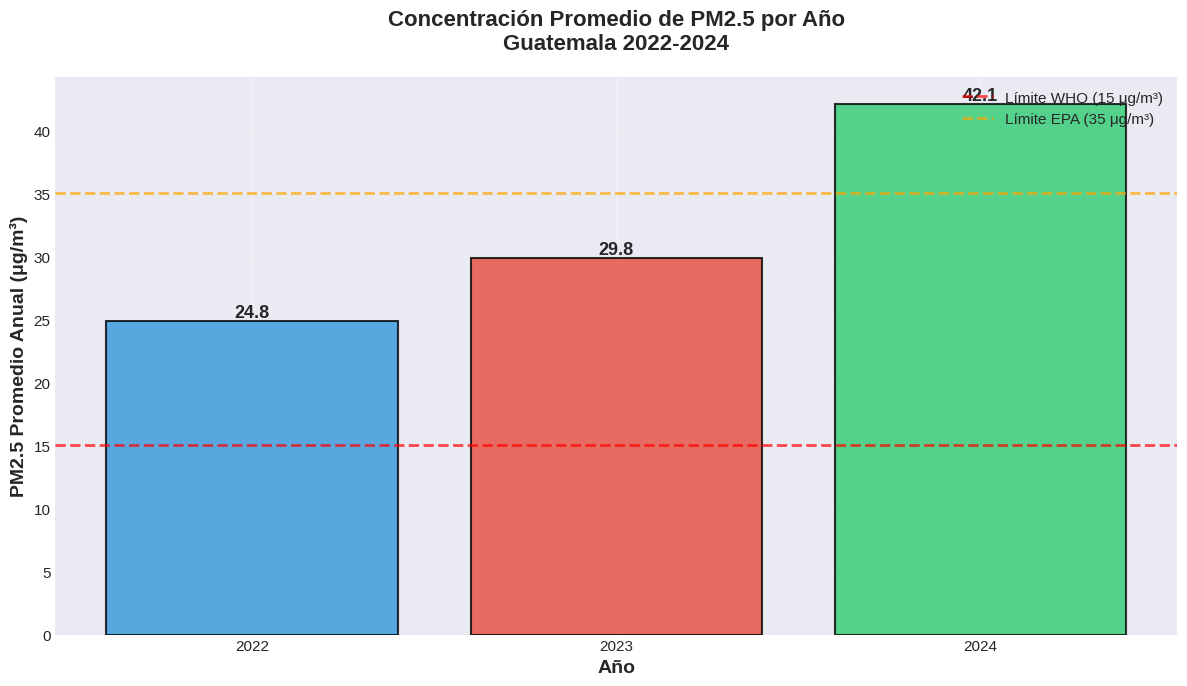

✓ Gráfico de PM2.5 anual generado


In [4]:
fig, ax = plt.subplots(figsize=(12, 7))

# Crear barras
bars = ax.bar(df_anual['anio'], df_anual['pm25_promedio'], 
              color=['#3498db', '#e74c3c', '#2ecc71'][:len(df_anual)],
              alpha=0.8, edgecolor='black', linewidth=1.5)

# Añadir valores sobre las barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}',
            ha='center', va='bottom', fontsize=13, fontweight='bold')

# Línea de referencia WHO (15 μg/m³)
ax.axhline(y=15, color='red', linestyle='--', linewidth=2, alpha=0.7, 
           label='Límite WHO (15 μg/m³)')

# Línea de referencia EPA (35 μg/m³)
ax.axhline(y=35, color='orange', linestyle='--', linewidth=2, alpha=0.7,
           label='Límite EPA (35 μg/m³)')

ax.set_xlabel('Año', fontsize=14, fontweight='bold')
ax.set_ylabel('PM2.5 Promedio Anual (μg/m³)', fontsize=14, fontweight='bold')
ax.set_title('Concentración Promedio de PM2.5 por Año\nGuatemala 2022-2024', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(df_anual['anio'])

plt.tight_layout()
plt.show()

print("✓ Gráfico de PM2.5 anual generado")

### 3.2 Gráfico de Barras: Vehículos Registrados por Año

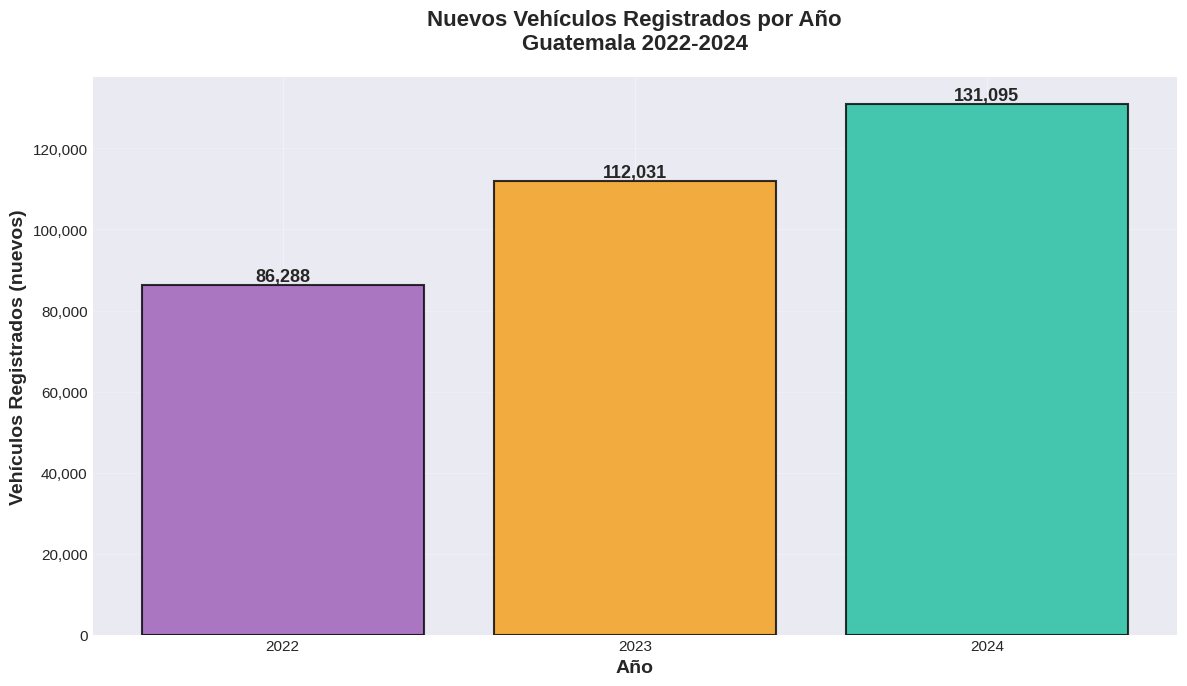

✓ Gráfico de vehículos anuales generado


In [5]:
fig, ax = plt.subplots(figsize=(12, 7))

# Crear barras
bars = ax.bar(df_anual['anio'], df_anual['total_vehiculos'], 
              color=['#9b59b6', '#f39c12', '#1abc9c'][:len(df_anual)],
              alpha=0.8, edgecolor='black', linewidth=1.5)

# Añadir valores sobre las barras
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height):,}',
            ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.set_xlabel('Año', fontsize=14, fontweight='bold')
ax.set_ylabel('Vehículos Registrados (nuevos)', fontsize=14, fontweight='bold')
ax.set_title('Nuevos Vehículos Registrados por Año\nGuatemala 2022-2024', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)
ax.set_xticks(df_anual['anio'])

# Formato de números con separador de miles
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

plt.tight_layout()
plt.show()

print("✓ Gráfico de vehículos anuales generado")

### 3.3 Gráfico Dual: PM2.5 vs. Vehículos (Barras Agrupadas)

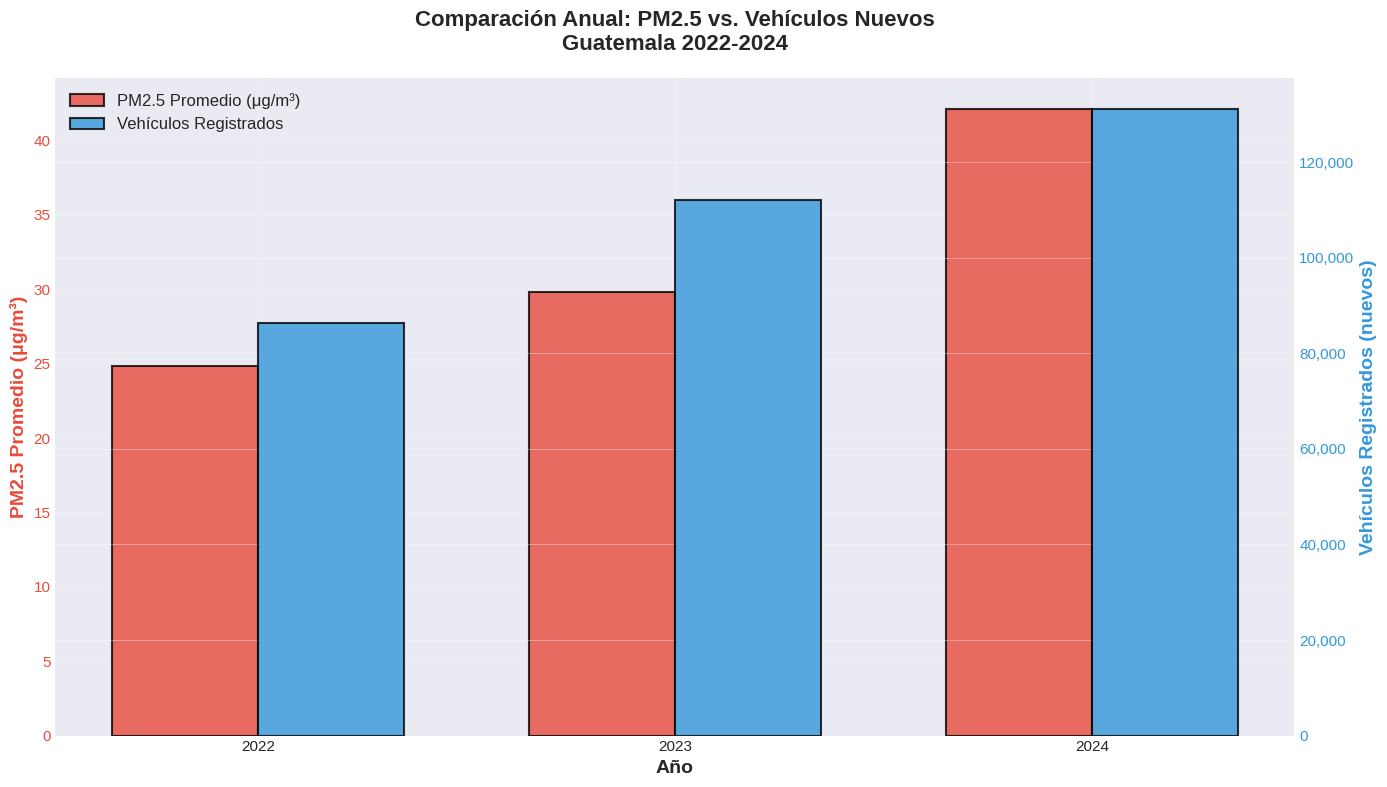

✓ Gráfico dual generado


In [6]:
fig, ax1 = plt.subplots(figsize=(14, 8))

# Normalizar datos para comparación visual
# PM2.5: escala original
# Vehículos: escalar para que se vea en misma gráfica

x = np.arange(len(df_anual['anio']))
width = 0.35

# Eje 1: PM2.5
bars1 = ax1.bar(x - width/2, df_anual['pm25_promedio'], width,
                label='PM2.5 Promedio (μg/m³)', color='#e74c3c', alpha=0.8,
                edgecolor='black', linewidth=1.5)

ax1.set_xlabel('Año', fontsize=14, fontweight='bold')
ax1.set_ylabel('PM2.5 Promedio (μg/m³)', fontsize=14, fontweight='bold', color='#e74c3c')
ax1.tick_params(axis='y', labelcolor='#e74c3c')
ax1.set_xticks(x)
ax1.set_xticklabels(df_anual['anio'])

# Eje 2: Vehículos
ax2 = ax1.twinx()
bars2 = ax2.bar(x + width/2, df_anual['total_vehiculos'], width,
                label='Vehículos Registrados', color='#3498db', alpha=0.8,
                edgecolor='black', linewidth=1.5)

ax2.set_ylabel('Vehículos Registrados (nuevos)', fontsize=14, fontweight='bold', color='#3498db')
ax2.tick_params(axis='y', labelcolor='#3498db')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Título
plt.title('Comparación Anual: PM2.5 vs. Vehículos Nuevos\nGuatemala 2022-2024', 
          fontsize=16, fontweight='bold', pad=20)

# Leyenda combinada
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=12)

ax1.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Gráfico dual generado")

### 3.4 Gráfico de Cambio Porcentual Año a Año

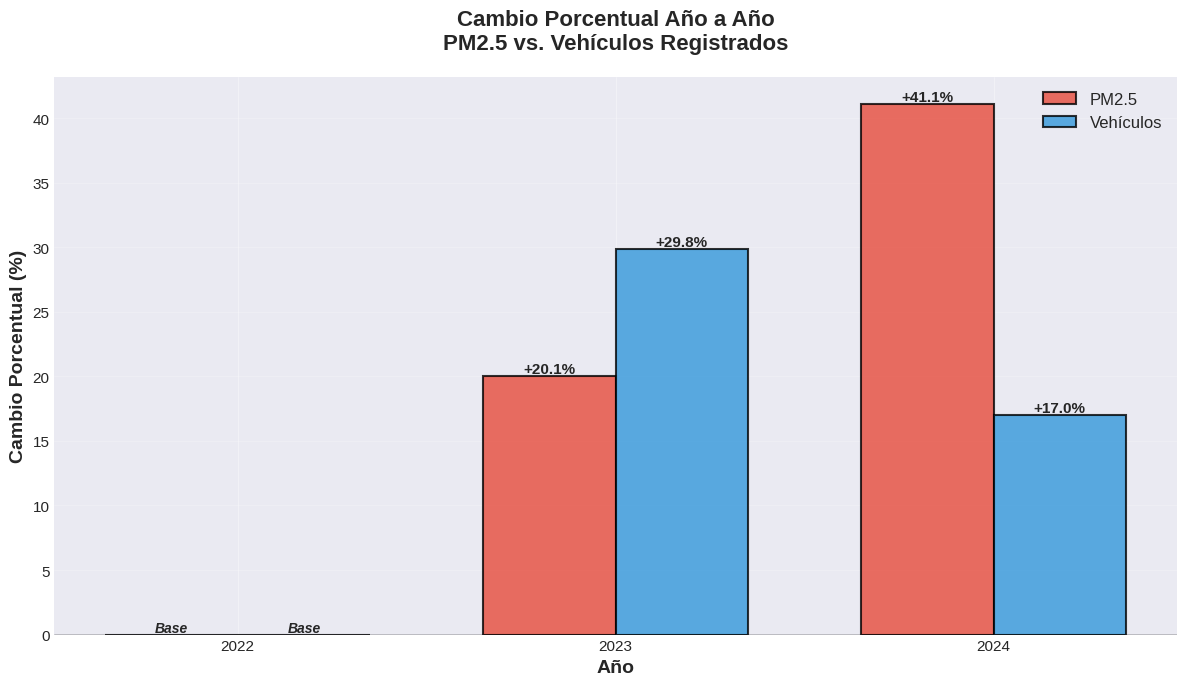

✓ Gráfico de cambios porcentuales generado (todos los años)


In [14]:
# Preparar datos de cambio (incluir todos los años, primer año con 0%)
df_cambio = df_anual.copy()

# Para el primer año, establecer cambio en 0% (o None para no mostrarlo)
# Opción 1: Mostrar 0% en el primer año
df_cambio['pm25_cambio_pct'] = df_cambio['pm25_cambio_pct'].fillna(0)
df_cambio['vehiculos_cambio_pct'] = df_cambio['vehiculos_cambio_pct'].fillna(0)

if len(df_cambio) > 0:
    fig, ax = plt.subplots(figsize=(12, 7))

    x = np.arange(len(df_cambio['anio']))
    width = 0.35

    # Barras PM2.5
    colors_pm25 = ['#27ae60' if v < 0 else '#e74c3c' for v in df_cambio['pm25_cambio_pct']]
    bars1 = ax.bar(x - width/2, df_cambio['pm25_cambio_pct'], width,
                   label='PM2.5', color=colors_pm25, alpha=0.8,
                   edgecolor='black', linewidth=1.5)

    # Barras Vehículos
    colors_veh = ['#27ae60' if v < 0 else '#3498db' for v in df_cambio['vehiculos_cambio_pct']]
    bars2 = ax.bar(x + width/2, df_cambio['vehiculos_cambio_pct'], width,
                   label='Vehículos', color=colors_veh, alpha=0.8,
                   edgecolor='black', linewidth=1.5)

    # Añadir valores (solo si el cambio no es 0)
    for bars in [bars1, bars2]:
        for i, bar in enumerate(bars):
            height = bar.get_height()
            # Solo mostrar texto si no es el primer año (cambio = 0)
            if i > 0 or height != 0:  # Esto evita mostrar "0.0%" en el primer año
                ax.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:+.1f}%',
                        ha='center', va='bottom' if height > 0 else 'top',
                        fontsize=11, fontweight='bold')
            else:
                # Para el primer año, mostrar "Base"
                ax.text(bar.get_x() + bar.get_width()/2., 0,
                        'Base',
                        ha='center', va='bottom',
                        fontsize=10, fontweight='bold', style='italic')

    # Línea de referencia en 0
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)

    ax.set_xlabel('Año', fontsize=14, fontweight='bold')
    ax.set_ylabel('Cambio Porcentual (%)', fontsize=14, fontweight='bold')
    ax.set_title('Cambio Porcentual Año a Año\nPM2.5 vs. Vehículos Registrados',
                 fontsize=16, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(df_cambio['anio'])
    ax.legend(fontsize=12)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("✓ Gráfico de cambios porcentuales generado (todos los años)")
else:
    print("⚠ No hay datos para generar el gráfico")

### 3.5 Box Plot: Distribución de PM2.5 por Año

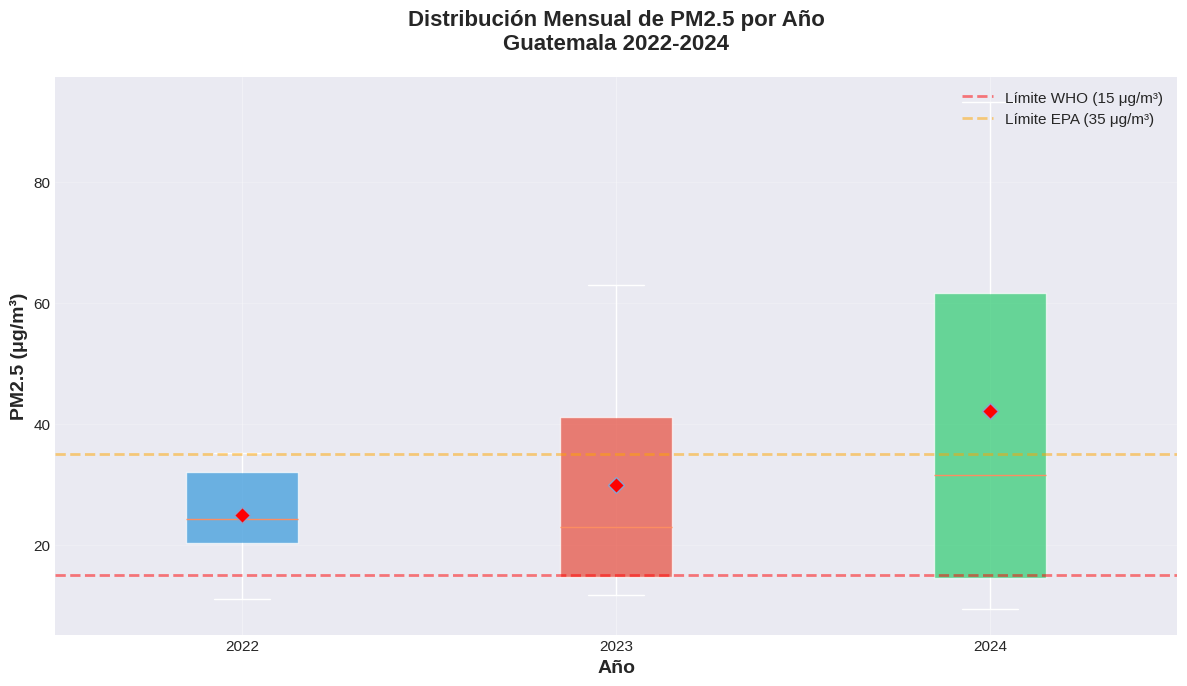

✓ Box plot generado

Leyenda: Rombo rojo = media, línea naranja = mediana


In [8]:
fig, ax = plt.subplots(figsize=(12, 7))

# Crear box plot usando datos mensuales
df_boxplot = df[['anio', 'pm25_promedio']].copy()

# Box plot
box_parts = ax.boxplot(
    [df_boxplot[df_boxplot['anio'] == year]['pm25_promedio'].values 
     for year in sorted(df_boxplot['anio'].unique())],
    labels=sorted(df_boxplot['anio'].unique()),
    patch_artist=True,
    showmeans=True,
    meanprops=dict(marker='D', markerfacecolor='red', markersize=8)
)

# Colorear boxes
colors = ['#3498db', '#e74c3c', '#2ecc71']
for patch, color in zip(box_parts['boxes'], colors[:len(box_parts['boxes'])]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Líneas de referencia
ax.axhline(y=15, color='red', linestyle='--', linewidth=2, alpha=0.5,
           label='Límite WHO (15 μg/m³)')
ax.axhline(y=35, color='orange', linestyle='--', linewidth=2, alpha=0.5,
           label='Límite EPA (35 μg/m³)')

ax.set_xlabel('Año', fontsize=14, fontweight='bold')
ax.set_ylabel('PM2.5 (μg/m³)', fontsize=14, fontweight='bold')
ax.set_title('Distribución Mensual de PM2.5 por Año\nGuatemala 2022-2024', 
             fontsize=16, fontweight='bold', pad=20)
ax.legend(loc='upper right', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Box plot generado")
print("\nLeyenda: Rombo rojo = media, línea naranja = mediana")

### 3.6 Heatmap: PM2.5 Mensual por Año

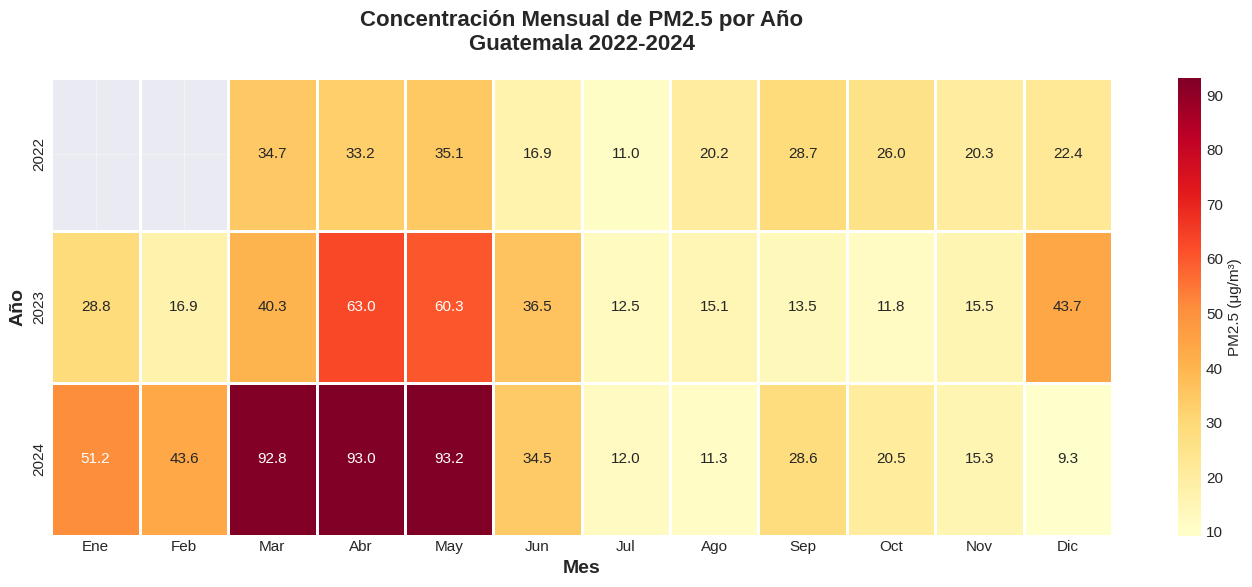

✓ Heatmap generado

Colores más oscuros indican mayor concentración de PM2.5


In [9]:
# Crear tabla pivote: Año x Mes
df['mes'] = df['fecha_pm25'].dt.month
df_pivot = df.pivot_table(
    values='pm25_promedio',
    index='anio',
    columns='mes',
    aggfunc='mean'
)

# Nombres de meses
meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 
         'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

fig, ax = plt.subplots(figsize=(14, 6))

# Heatmap
sns.heatmap(
    df_pivot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    cbar_kws={'label': 'PM2.5 (μg/m³)'},
    linewidths=1,
    linecolor='white',
    ax=ax
)

ax.set_xlabel('Mes', fontsize=14, fontweight='bold')
ax.set_ylabel('Año', fontsize=14, fontweight='bold')
ax.set_title('Concentración Mensual de PM2.5 por Año\nGuatemala 2022-2024', 
             fontsize=16, fontweight='bold', pad=20)

# Etiquetas de meses
ax.set_xticklabels([meses[int(col)-1] if col <= 12 else '' 
                    for col in df_pivot.columns], rotation=0)

plt.tight_layout()
plt.show()

print("✓ Heatmap generado")
print("\nColores más oscuros indican mayor concentración de PM2.5")

---
## 4. Análisis Mensual Detallado por Año

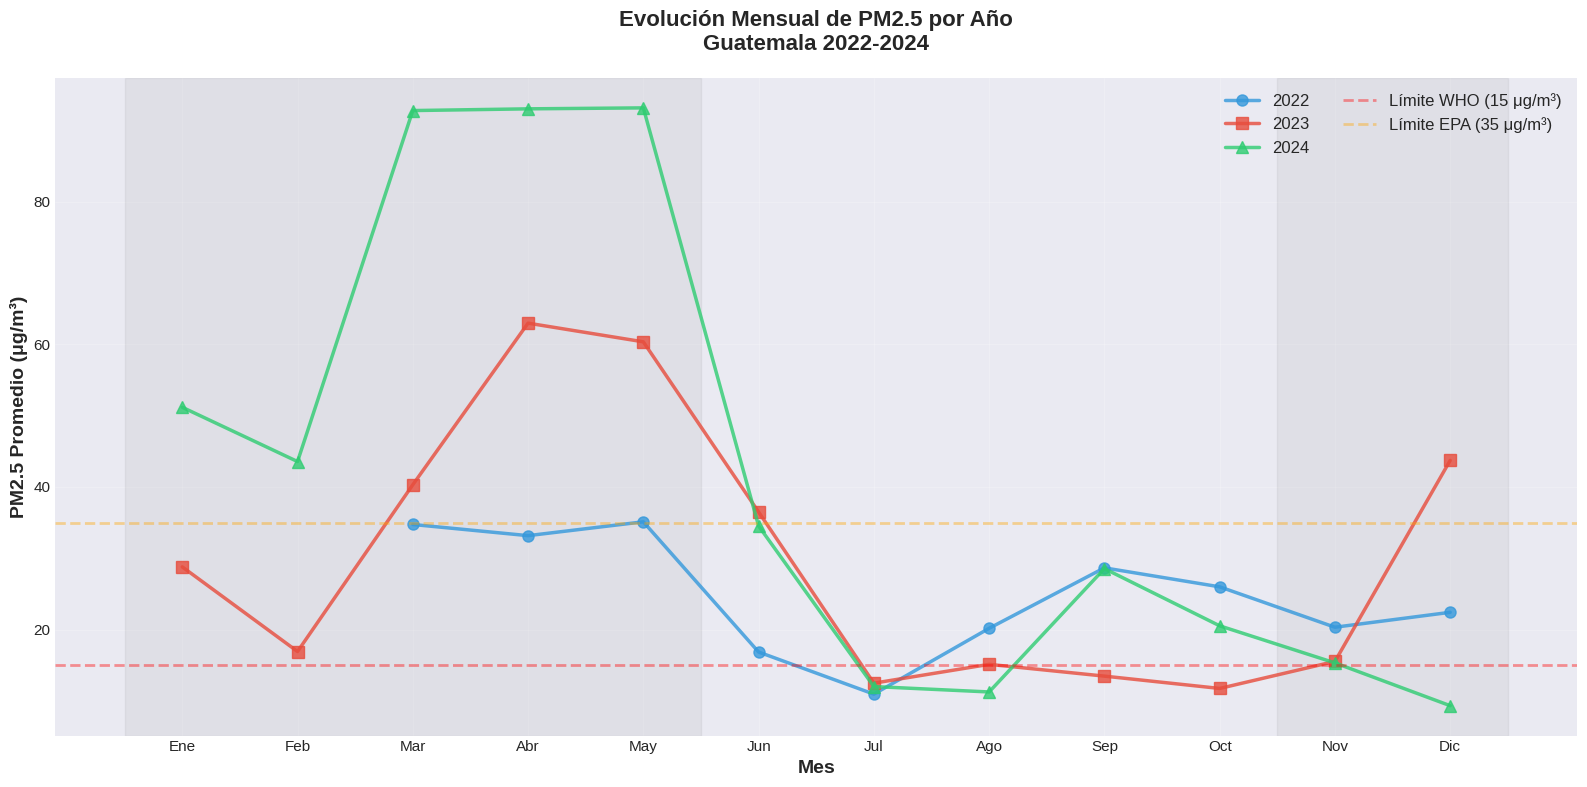

✓ Gráfico de evolución mensual generado


In [10]:
# Gráfico de líneas: Evolución mensual separada por año
fig, ax = plt.subplots(figsize=(16, 8))

# Crear una línea por cada año
colors_years = {'2022': '#3498db', '2023': '#e74c3c', '2024': '#2ecc71'}
markers = {'2022': 'o', '2023': 's', '2024': '^'}

for year in sorted(df['anio'].unique()):
    df_year = df[df['anio'] == year].sort_values('mes')
    ax.plot(df_year['mes'], df_year['pm25_promedio'],
            marker=markers.get(str(year), 'o'),
            linewidth=2.5,
            markersize=8,
            label=f'{year}',
            color=colors_years.get(str(year), 'gray'),
            alpha=0.8)

# Líneas de referencia
ax.axhline(y=15, color='red', linestyle='--', linewidth=2, alpha=0.4,
           label='Límite WHO (15 μg/m³)')
ax.axhline(y=35, color='orange', linestyle='--', linewidth=2, alpha=0.4,
           label='Límite EPA (35 μg/m³)')

ax.set_xlabel('Mes', fontsize=14, fontweight='bold')
ax.set_ylabel('PM2.5 Promedio (μg/m³)', fontsize=14, fontweight='bold')
ax.set_title('Evolución Mensual de PM2.5 por Año\nGuatemala 2022-2024', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses)
ax.legend(loc='best', fontsize=12, ncol=2)
ax.grid(True, alpha=0.3)

# Sombreado de época seca (Nov-May)
ax.axvspan(0.5, 5.5, alpha=0.1, color='gray', label='Época Seca (Nov-May)')
ax.axvspan(10.5, 12.5, alpha=0.1, color='gray')

plt.tight_layout()
plt.show()

print("✓ Gráfico de evolución mensual generado")

---
## 5. Tabla Resumen Comparativa

In [11]:
# Crear tabla resumen
print("="*100)
print("RESUMEN COMPARATIVO ANUAL - GUATEMALA 2022-2024")
print("="*100)

resumen = df_anual[[
    'anio',
    'pm25_promedio',
    'pm25_min',
    'pm25_max',
    'total_vehiculos',
    'pm25_cambio_pct',
    'vehiculos_cambio_pct'
]].copy()

resumen.columns = [
    'Año',
    'PM2.5 Promedio\n(μg/m³)',
    'PM2.5 Mínimo\n(μg/m³)',
    'PM2.5 Máximo\n(μg/m³)',
    'Vehículos\nRegistrados',
    'Δ PM2.5\n(%)',
    'Δ Vehículos\n(%)'
]

# Formatear para mejor visualización
resumen_display = resumen.copy()
resumen_display['Vehículos\nRegistrados'] = resumen_display['Vehículos\nRegistrados'].apply(lambda x: f"{int(x):,}")

for col in ['PM2.5 Promedio\n(μg/m³)', 'PM2.5 Mínimo\n(μg/m³)', 'PM2.5 Máximo\n(μg/m³)']:
    resumen_display[col] = resumen_display[col].apply(lambda x: f"{x:.1f}")

for col in ['Δ PM2.5\n(%)', 'Δ Vehículos\n(%)']:
    resumen_display[col] = resumen_display[col].apply(
        lambda x: f"{x:+.1f}%" if pd.notna(x) else "N/A"
    )

display(resumen_display)

print("\n" + "="*100)
print("OBSERVACIONES:")
print("="*100)

# Análisis automático
pm25_2022 = df_anual[df_anual['anio'] == 2022]['pm25_promedio'].values[0] if 2022 in df_anual['anio'].values else None
pm25_2024 = df_anual[df_anual['anio'] == 2024]['pm25_promedio'].values[0] if 2024 in df_anual['anio'].values else None

if pm25_2022 and pm25_2024:
    cambio_total = ((pm25_2024 - pm25_2022) / pm25_2022) * 100
    print(f"\n1. TENDENCIA PM2.5 (2022 → 2024):")
    print(f"   - Cambio total: {cambio_total:+.1f}%")
    if cambio_total > 0:
        print(f"   - ⚠️  La concentración de PM2.5 AUMENTÓ en el periodo")
    else:
        print(f"   - ✓ La concentración de PM2.5 DISMINUYÓ en el periodo")

print(f"\n2. LÍMITES DE REFERENCIA:")
for idx, row in df_anual.iterrows():
    year = int(row['anio'])
    pm25 = row['pm25_promedio']
    
    if pm25 > 35:
        print(f"   - {year}: ⚠️  EXCEDE límite EPA (35 μg/m³) → {pm25:.1f} μg/m³")
    elif pm25 > 15:
        print(f"   - {year}: ⚠️  EXCEDE límite WHO (15 μg/m³) → {pm25:.1f} μg/m³")
    else:
        print(f"   - {year}: ✓ Dentro de límites WHO → {pm25:.1f} μg/m³")

print(f"\n3. VEHÍCULOS REGISTRADOS:")
total_vehiculos_periodo = df_anual['total_vehiculos'].sum()
print(f"   - Total registrados (2022-2024): {int(total_vehiculos_periodo):,} vehículos")
print(f"   - Promedio anual: {int(total_vehiculos_periodo/len(df_anual)):,} vehículos/año")

print("\n" + "="*100)

RESUMEN COMPARATIVO ANUAL - GUATEMALA 2022-2024


,Año,PM2.5 Promedio\n(μg/m³),PM2.5 Mínimo\n(μg/m³),PM2.5 Máximo\n(μg/m³),Vehículos\nRegistrados,Δ PM2.5\n(%),Δ Vehículos\n(%)
0,2022,24.8,0.0,1364.0,"86,288",N/A,N/A
1,2023,29.8,0.0,1928.0,"112,031",+20.1%,+29.8%
2,2024,42.1,0.0,1198.0,"131,095",+41.1%,+17.0%



OBSERVACIONES:

1. TENDENCIA PM2.5 (2022 → 2024):
   - Cambio total: +69.5%
   - ⚠️  La concentración de PM2.5 AUMENTÓ en el periodo

2. LÍMITES DE REFERENCIA:
   - 2022: ⚠️  EXCEDE límite WHO (15 μg/m³) → 24.8 μg/m³
   - 2023: ⚠️  EXCEDE límite WHO (15 μg/m³) → 29.8 μg/m³
   - 2024: ⚠️  EXCEDE límite EPA (35 μg/m³) → 42.1 μg/m³

3. VEHÍCULOS REGISTRADOS:
   - Total registrados (2022-2024): 329,414 vehículos
   - Promedio anual: 109,804 vehículos/año



---
## 6. Exportar Resultados

In [12]:
# Guardar datos anuales
df_anual.to_csv('resultados_anuales_pm25_vehiculos.csv', index=False)
print("✓ Datos anuales exportados: resultados_anuales_pm25_vehiculos.csv")

# Guardar datos mensuales con año y mes
df_export = df[[
    'fecha_pm25', 'anio', 'mes',
    'pm25_promedio', 'pm25_std', 'pm25_min', 'pm25_max',
    'total_vehiculos', 'n_mediciones'
]].copy()
df_export.to_csv('resultados_mensuales_pm25_vehiculos.csv', index=False)
print("✓ Datos mensuales exportados: resultados_mensuales_pm25_vehiculos.csv")

print("\n✅ ANÁLISIS COMPLETADO")

✓ Datos anuales exportados: resultados_anuales_pm25_vehiculos.csv
✓ Datos mensuales exportados: resultados_mensuales_pm25_vehiculos.csv

✅ ANÁLISIS COMPLETADO
